# Proyecto 2 — Análisis Inicial y Selección de Problema

**Etapa:** Parte I — Búsqueda, EDA inicial y Selección de Problema  

---

##Datasets analizados

| # | Dataset | Fuente | Dominio | Problema |
|---|---------|--------|---------|----------|
| 1 | Bank Customer Churn | Kaggle | Banca / Finanzas | Clasificación |
| 2 | Heart Disease | Kaggle | Salud / Medicina | Clasificación |
| 3 | Video Game Sales + Metacritic | Kaggle | Entretenimiento | Regresión |
| 4 | Most Streamed Spotify Songs 2024 | Kaggle | Música / Streaming | Regresión |

---


# Diccionario de Columnas — Proyecto 2

---

##  Dataset 3 — Video Game Sales & Metacritic
**Archivo:** `games.csv` | **Filas:** 50.000 | **Columnas:** 35

| # | Columna (original) | Traducción | Tipo | Descripción |
|---|---|---|---|---|
| 1 | game_id | ID del juego | str | Identificador único del juego |
| 2 | title | Título | str | Nombre del videojuego |
| 3 | platform | Plataforma | str | Consola o plataforma en la que fue lanzado (PS4, Xbox, Wii, etc.) |
| 4 | platform_type | Tipo de plataforma | str | Categoría de la plataforma (Console = Consola / Handheld = Portátil / PC) |
| 5 | platform_maker | Fabricante de la plataforma | str | Empresa que fabricó la plataforma (Nintendo, Sony, Microsoft, etc.) |
| 6 | platform_generation | Generación de la plataforma | int | Número de generación de la plataforma (ej. 6, 7, 8) |
| 7 | genre | Género | str | Género del videojuego (Action, Sports, RPG, etc.) |
| 8 | year | Año de lanzamiento | int | Año en que fue lanzado el juego |
| 9 | publisher | Publicadora | str | Empresa que publicó el juego |
| 10 | developer | Desarrolladora | str | Empresa que desarrolló el juego |
| 11 | publisher_region | Región de la publicadora | str | Región de origen de la empresa publicadora |
| 12 | publisher_tier | Categoría de la publicadora | str | Nivel de la publicadora (AAA, Indie, etc.) |
| 13 | esrb_rating | Clasificación ESRB | str | Clasificación por edades según la ESRB (E = Para todos, T = Adolescentes, M = Maduros, etc.) |
| 14 | metacritic_score | Puntuación Metacritic | int | Puntuación de críticos profesionales en Metacritic (0–100) |
| 15 | user_score | Puntuación de usuarios | float | Puntuación otorgada por los usuarios en Metacritic (0–10) |
| 16 | critic_review_count | N° de reseñas de críticos | int | Cantidad de reseñas de críticos profesionales recibidas |
| 17 | user_review_count | N° de reseñas de usuarios | int | Cantidad de reseñas de usuarios recibidas |
| 18 | na_sales_million | Ventas Norteamérica (M) | float | Ventas totales en Norteamérica en millones de unidades |
| 19 | eu_sales_million | Ventas Europa (M) | float | Ventas totales en Europa en millones de unidades |
| 20 | jp_sales_million | Ventas Japón (M) | float | Ventas totales en Japón en millones de unidades |
| 21 | other_sales_million | Otras ventas (M) | float | Ventas en el resto del mundo en millones de unidades |
| 22 | **global_sales_million** | **Ventas globales (M)** | float | **Variable objetivo: total de ventas mundiales en millones de unidades** |
| 23 | estimated_revenue_million_usd | Ingresos estimados (M USD) | float | Ingresos totales estimados del juego en millones de dólares |
| 24 | launch_price_usd | Precio de lanzamiento (USD) | float | Precio del juego al momento de su lanzamiento en dólares |
| 25 | is_sequel | ¿Es secuela? | int | Indica si el juego es continuación de otro título (1 = Sí / 0 = No) |
| 26 | online_multiplayer | ¿Tiene multijugador en línea? | int | Indica si el juego tiene modo multijugador online (1 = Sí / 0 = No) |
| 27 | dlc_released | ¿Tiene DLC? | int | Indica si se lanzó contenido descargable adicional (1 = Sí / 0 = No) |
| 28 | microtransactions | ¿Tiene microtransacciones? | int | Indica si el juego incluye microtransacciones (1 = Sí / 0 = No) |
| 29 | loot_boxes | ¿Tiene cajas de recompensa? | int | Indica si el juego incluye loot boxes (1 = Sí / 0 = No) |
| 30 | game_pass_available | ¿Disponible en Game Pass? | int | Indica si el juego está disponible en Xbox Game Pass (1 = Sí / 0 = No) |
| 31 | vr_support | ¿Tiene soporte VR? | int | Indica si el juego es compatible con realidad virtual (1 = Sí / 0 = No) |
| 32 | goty_nominated | ¿Nominado a GOTY? | int | Indica si el juego fue nominado a Juego del Año (1 = Sí / 0 = No) |
| 33 | goty_won | ¿Ganó GOTY? | int | Indica si el juego ganó el premio Juego del Año (1 = Sí / 0 = No) |
| 34 | how_long_to_beat_main_hrs | Horas — historia principal | float | Horas estimadas para completar únicamente la historia principal |
| 35 | how_long_to_beat_completionist_hrs | Horas — completar al 100% | float | Horas estimadas para completar el juego al 100% incluyendo todo el contenido |

---


---
# Sección 0 — Configuración del entorno

Lo primero que debemos hacer es conectarnos al drive para poder acceder a los dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Librerías
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

In [ ]:
#  Función reutilizable: resumen de nulos
def resumen_nulos(df, titulo=''):
    null_df = pd.DataFrame({
        'Nulos': df.isnull().sum(),
        '% Nulos': (df.isnull().sum() / len(df) * 100).round(1)
    }).sort_values('% Nulos', ascending=False)
    null_df = null_df[null_df['Nulos'] > 0]
    if null_df.empty:
        print(f'{titulo}: Sin valores nulos.')
        return null_df
    print(f'\n Nulos en {titulo}:')
    print(null_df.to_string())
    return null_df

# Función reutilizable: outliers IQR
def resumen_outliers(df, cols, nombre=''):
    rows = []
    for col in cols:
        if col not in df.columns: continue
        data = df[col].dropna()
        Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
        IQR = Q3 - Q1
        n = ((data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)).sum()
        rows.append({
            'Variable': col, 'Q1': round(Q1, 2), 'Q3': round(Q3, 2),
            'IQR': round(IQR, 2), 'N Outliers': n,
            '% Outliers': round(n / len(data) * 100, 2)
        })
    result = pd.DataFrame(rows)
    if not result.empty:
        print(f'\n [{nombre}] Resumen de outliers (método IQR):')
        display(result)
    return result


---
# Dataset 3 — Video Game Sales & Metacritic
**Fuente:** Kaggle — `meruvakodandasuraj/video-game-sales-and-metacritic-intelligence-198026`  
**Dominio:** Entretenimiento / Videojuegos  
**Problema:** Regresión — predecir ventas globales de un videojuego

## Descripción del conjunto de datos
50.000 registros de videojuegos con datos de ventas regionales, scores de Metacritic y características del juego.

| Columna | Traducción | Tipo | Descripción |
|---|---|---|---|
| game_id | ID del juego | str | Identificador único — sin valor predictivo |
| title | Título | str | Nombre del videojuego |
| platform | Plataforma | str | Consola o plataforma |
| platform_type | Tipo de plataforma | str | Console / Handheld / PC |
| platform_maker | Fabricante | str | Nintendo / Sony / Microsoft |
| platform_generation | Generación | int | Número de generación de la plataforma |
| genre | Género | str | Género del juego |
| year | Año | int | Año de lanzamiento |
| publisher | Publicadora | str | Empresa que publicó el juego |
| developer | Desarrolladora | str | Empresa que desarrolló el juego |
| publisher_region | Región publicadora | str | Origen geográfico de la publicadora |
| publisher_tier | Categoría publicadora | str | AAA / Indie / etc. |
| esrb_rating | Clasificación ESRB | str | E / T / M / AO |
| metacritic_score | Score Metacritic | int | Puntuación críticos (0–100) |
| user_score | Score usuarios | float | Puntuación usuarios (0–10) |
| critic_review_count | N° reseñas críticos | int | Cantidad de reseñas profesionales |
| user_review_count | N° reseñas usuarios | int | Cantidad de reseñas de usuarios |
| na_sales_million | Ventas NA (M) | float | Ventas Norteamérica |
| eu_sales_million | Ventas EU (M) | float | Ventas Europa |
| jp_sales_million | Ventas JP (M) | float | Ventas Japón |
| other_sales_million | Otras ventas (M) | float | Otras regiones |
| **global_sales_million** | **Ventas globales (M)** | float | **Target: ventas mundiales** |
| estimated_revenue_million_usd | Ingresos estimados (M USD) | float | Ingresos totales estimados |
| launch_price_usd | Precio lanzamiento | float | Precio en USD al lanzamiento |
| is_sequel | ¿Es secuela? | int | 1 = Sí / 0 = No |
| online_multiplayer | Multijugador online | int | 1 = Sí / 0 = No |
| dlc_released | ¿Tiene DLC? | int | 1 = Sí / 0 = No |
| microtransactions | Microtransacciones | int | 1 = Sí / 0 = No |
| loot_boxes | Cajas de recompensa | int | 1 = Sí / 0 = No |
| game_pass_available | Disponible en Game Pass | int | 1 = Sí / 0 = No |
| vr_support | Soporte VR | int | 1 = Sí / 0 = No |
| goty_nominated | Nominado GOTY | int | 1 = Sí / 0 = No |
| goty_won | Ganó GOTY | int | 1 = Sí / 0 = No |
| how_long_to_beat_main_hrs | Horas historia principal | float | Horas para terminar la historia |
| how_long_to_beat_completionist_hrs | Horas al 100% | float | Horas para completar al 100% |

## 3.2 Descarga y carga de datos

In [ ]:
df_game = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/datasets/VideoGames/games.csv', encoding='latin-1')
df_game.columns = df_game.columns.str.strip()

print(f'✅ df_game cargado: {df_game.shape[0]:,} filas × {df_game.shape[1]} columnas')
print(f'Columnas: {df_game.columns.tolist()}')
df_game.head()

✅ df_game cargado: 50,000 filas × 35 columnas
Columnas: ['game_id', 'title', 'platform', 'platform_type', 'platform_maker', 'platform_generation', 'genre', 'year', 'publisher', 'developer', 'publisher_region', 'publisher_tier', 'esrb_rating', 'metacritic_score', 'user_score', 'critic_review_count', 'user_review_count', 'na_sales_million', 'eu_sales_million', 'jp_sales_million', 'other_sales_million', 'global_sales_million', 'estimated_revenue_million_usd', 'launch_price_usd', 'is_sequel', 'online_multiplayer', 'dlc_released', 'microtransactions', 'loot_boxes', 'game_pass_available', 'vr_support', 'goty_nominated', 'goty_won', 'how_long_to_beat_main_hrs', 'how_long_to_beat_completionist_hrs']


,game_id,title,platform,platform_type,platform_maker,platform_generation,genre,year,publisher,developer,...,online_multiplayer,dlc_released,microtransactions,loot_boxes,game_pass_available,vr_support,goty_nominated,goty_won,how_long_to_beat_main_hrs,how_long_to_beat_completionist_hrs
0,G000001,eFootball 2023,Game Boy,Handheld,Nintendo,4,Sports,1990,CD Projekt,Deep Silver,...,1,1,0,0,0,0,0,0,31.8,86.1
1,G000002,Doom 3,Xbox,Console,Microsoft,6,Rhythm,2004,Ubisoft,Ubisoft,...,0,1,1,0,0,0,0,0,13.1,55.4
2,G000003,God of Fire,PC,PC,Various,0,Misc,1988,Microsoft Studios,Microsoft Studios,...,0,0,0,0,0,0,0,0,9.8,20.9
3,G000004,Call of Duty: Rising Sun,Mobile (Android),Mobile,Google,0,Shooter,2017,InXile Entertainment,InXile Entertainment,...,1,1,1,0,0,0,0,0,9.1,44.8
4,G000005,Fortnite 3,Nintendo 64,Console,Nintendo,5,Battle Royale,1999,Naughty Dog,id Software,...,1,0,1,0,0,0,0,0,150.8,322.3


In [ ]:
# Eliminar columna ID sin valor predictivo
df_game.drop(columns=[c for c in ['game_id'] if c in df_game.columns], inplace=True)

# Convertir year a int si tiene nulos
if 'year' in df_game.columns:
    df_game['year'] = pd.to_numeric(df_game['year'], errors='coerce')
    print('\nColumna year convertida a numérico')


Columna year convertida a numérico


## 3.3 Análisis estadístico descriptivo

In [ ]:
print(f'Informacion del dataset: \n')
df_game.info()

print(f'\nPrimeras 5 filas: \n\n {df_game.head()}\n')
print(f'Últimas 5 filas: \n\n {df_game.tail()}\n')
print(f'Cantidad de elementos duplicados:\n\n {df_game.duplicated()}\n')
print(f'Cantidad de elementos nulos:\n \n{df_game.isnull().sum()}\n')
print(f'Tipos de datos :\n \n {df_game.dtypes.to_string()}')
num3 = df_game.select_dtypes(include=np.number)
desc3 = num3.describe().T
desc3['skewness'] = num3.skew().round(3)
display(desc3.style.background_gradient(cmap='Blues', subset=['mean','std']))


Informacion del dataset: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 34 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   title                               50000 non-null  object 
 1   platform                            50000 non-null  object 
 2   platform_type                       50000 non-null  object 
 3   platform_maker                      50000 non-null  object 
 4   platform_generation                 50000 non-null  int64  
 5   genre                               50000 non-null  object 
 6   year                                50000 non-null  int64  
 7   publisher                           50000 non-null  object 
 8   developer                           50000 non-null  object 
 9   publisher_region                    50000 non-null  object 
 10  publisher_tier                      50000 non-null  object 
 11  esrb_rating   

,count,mean,std,min,25%,50%,75%,max,skewness
platform_generation,50000.000000,4.397120,3.256757,0.000000,0.000000,5.000000,7.000000,10.000000,-0.150000
year,50000.000000,2007.479640,11.673832,1985.000000,1998.000000,2008.000000,2017.000000,2026.000000,-0.189000
metacritic_score,50000.000000,74.046480,8.626383,37.000000,68.000000,74.000000,80.000000,99.000000,-0.063000
user_score,50000.000000,7.407888,1.160381,2.200000,6.600000,7.400000,8.200000,10.000000,-0.102000
critic_review_count,50000.000000,27.290160,26.261779,0.000000,11.000000,20.000000,34.000000,636.000000,3.527000
user_review_count,50000.000000,470.612300,894.567299,0.000000,91.000000,221.000000,515.000000,39129.000000,11.224000
na_sales_million,50000.000000,11.946759,20.717035,0.030000,2.420000,5.940000,13.420000,769.070000,8.122000
eu_sales_million,50000.000000,7.732016,13.477750,0.010000,1.510000,3.760000,8.632500,389.100000,7.281000
jp_sales_million,50000.000000,3.370298,7.439700,0.000000,0.400000,1.210000,3.330000,251.210000,8.887000
other_sales_million,50000.000000,2.985665,5.634561,0.010000,0.540000,1.380000,3.260000,300.560000,10.391000


## 3.3.1 Valores nulos

In [ ]:
nulos_game = resumen_nulos(df_game, 'df_game')

if not nulos_game.empty:
    print('\n Estrategia de tratamiento:')
    for col, row in nulos_game.iterrows():
        if row['% Nulos'] > 50:
            print(f'  {col} ({row["% Nulos"]}%): considerar eliminar la columna')
        elif df_game[col].dtype == 'object':
            print(f'  {col} ({row["% Nulos"]}%): imputar con moda o categoría "Unknown"')
            df_game[col].fillna('Unknown', inplace=True)
        else:
            print(f'  {col} ({row["% Nulos"]}%): imputar con mediana')
            df_game[col].fillna(df_game[col].median(), inplace=True)
    resumen_nulos(df_game, 'df_game — tras tratamiento')

df_game: Sin valores nulos.


## 3.3.2 Duplicados

In [ ]:
n_dup_game = df_game.duplicated().sum()
print(f'Filas duplicadas: {n_dup_game}')

if n_dup_game > 0:
    df_game.drop_duplicates(inplace=True)
    df_game.reset_index(drop=True, inplace=True)
    print(f' Duplicados eliminados. Shape actual: {df_game.shape}')
else:
    print(' Sin filas duplicadas.')

Filas duplicadas: 0
 Sin filas duplicadas.


## 3.4 Visualizaciones
### 3.4.1 Distribución de ventas (alta asimetría)

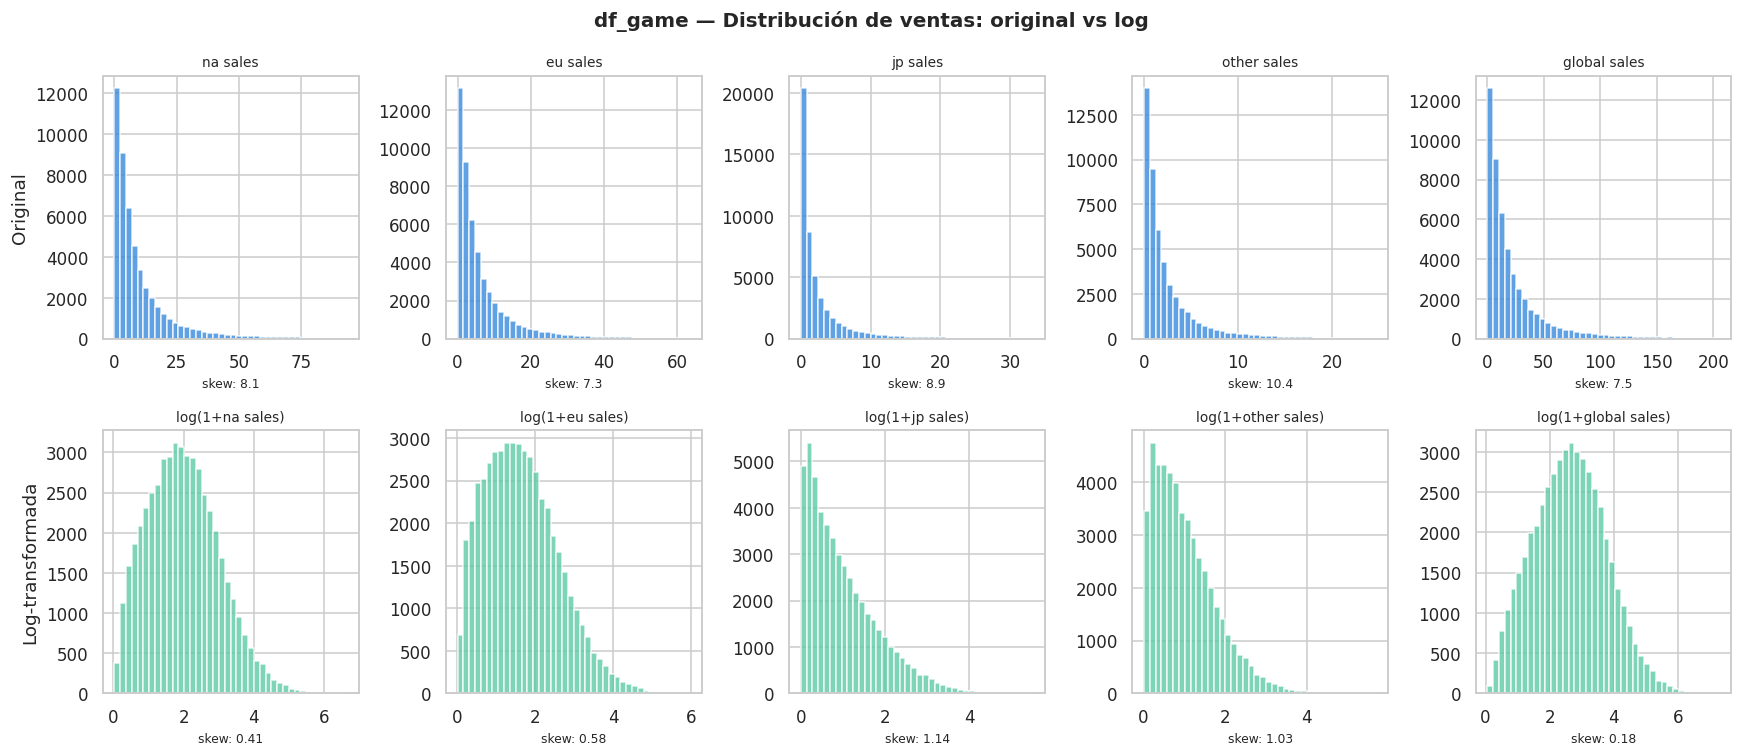

In [ ]:
# Ventas — distribución original vs log
sales_cols_game = ['na_sales_million', 'eu_sales_million', 'jp_sales_million',
                   'other_sales_million', 'global_sales_million']
sales_cols_game = [c for c in sales_cols_game if c in df_game.columns]

fig, axes = plt.subplots(2, len(sales_cols_game), figsize=(16, 7))

for i, col in enumerate(sales_cols_game):
    data = df_game[col].dropna()
    axes[0][i].hist(data[data <= data.quantile(0.99)], bins=40,
                    color='#378ADD', edgecolor='white', alpha=0.8)
    axes[0][i].set_title(col.replace('_million','').replace('_',' '), fontsize=9)
    axes[0][i].set_xlabel(f'skew: {data.skew():.1f}', fontsize=8)

    axes[1][i].hist(np.log1p(data), bins=40, color='#5DCAA5', edgecolor='white', alpha=0.8)
    axes[1][i].set_title(f'log(1+{col.replace("_million","").replace("_"," ")})', fontsize=9)
    axes[1][i].set_xlabel(f'skew: {np.log1p(data).skew():.2f}', fontsize=8)

axes[0][0].set_ylabel('Original')
axes[1][0].set_ylabel('Log-transformada')
plt.suptitle('df_game — Distribución de ventas: original vs log', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.4.2 Ventas por género y plataforma

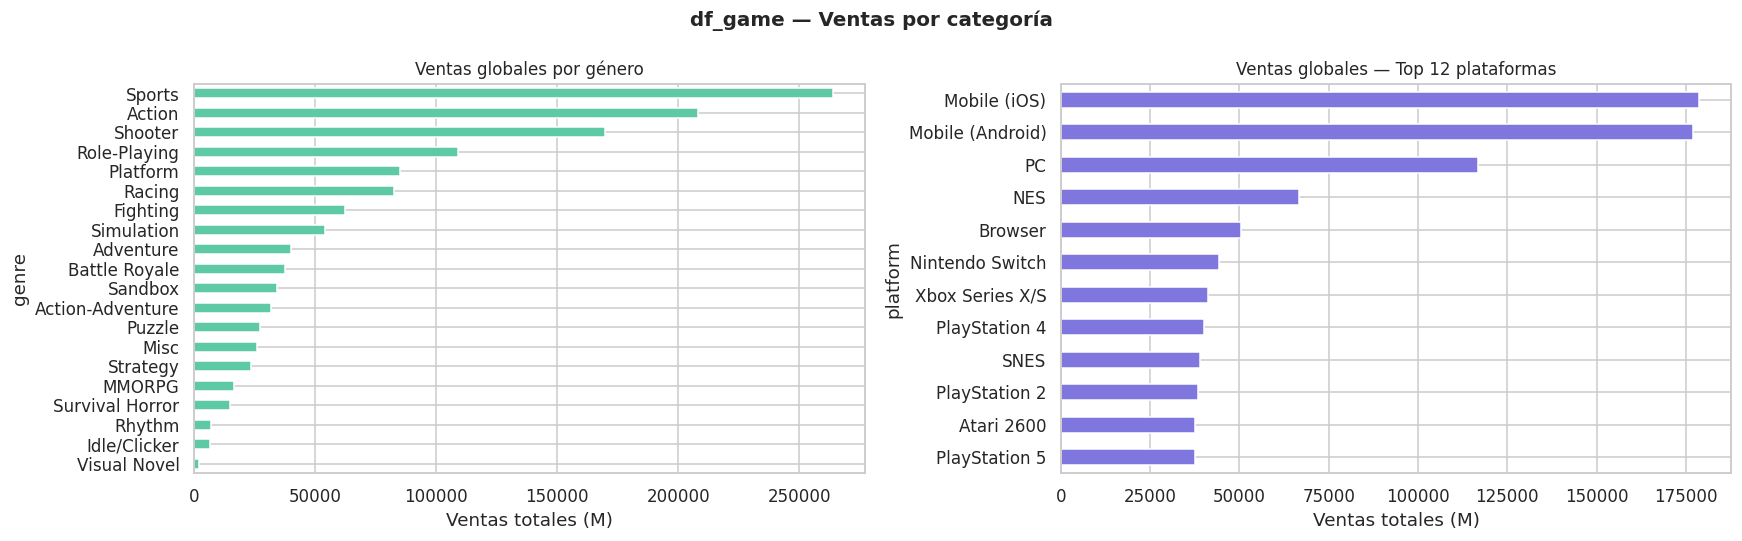

In [ ]:
# Ventas por género y plataforma
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

if 'genre' in df_game.columns:
    genre_game = df_game.groupby('genre')['global_sales_million'].sum().sort_values()
    genre_game.plot(kind='barh', ax=axes[0], color='#5DCAA5', edgecolor='white')
    axes[0].set_title('Ventas globales por género', fontsize=11)
    axes[0].set_xlabel('Ventas totales (M)')

if 'platform' in df_game.columns:
    plat_game = df_game.groupby('platform')['global_sales_million'].sum().sort_values().tail(12)
    plat_game.plot(kind='barh', ax=axes[1], color='#7F77DD', edgecolor='white')
    axes[1].set_title('Ventas globales — Top 12 plataformas', fontsize=11)
    axes[1].set_xlabel('Ventas totales (M)')

plt.suptitle('df_game — Ventas por categoría', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.4.3 Critic Score vs Global Sales

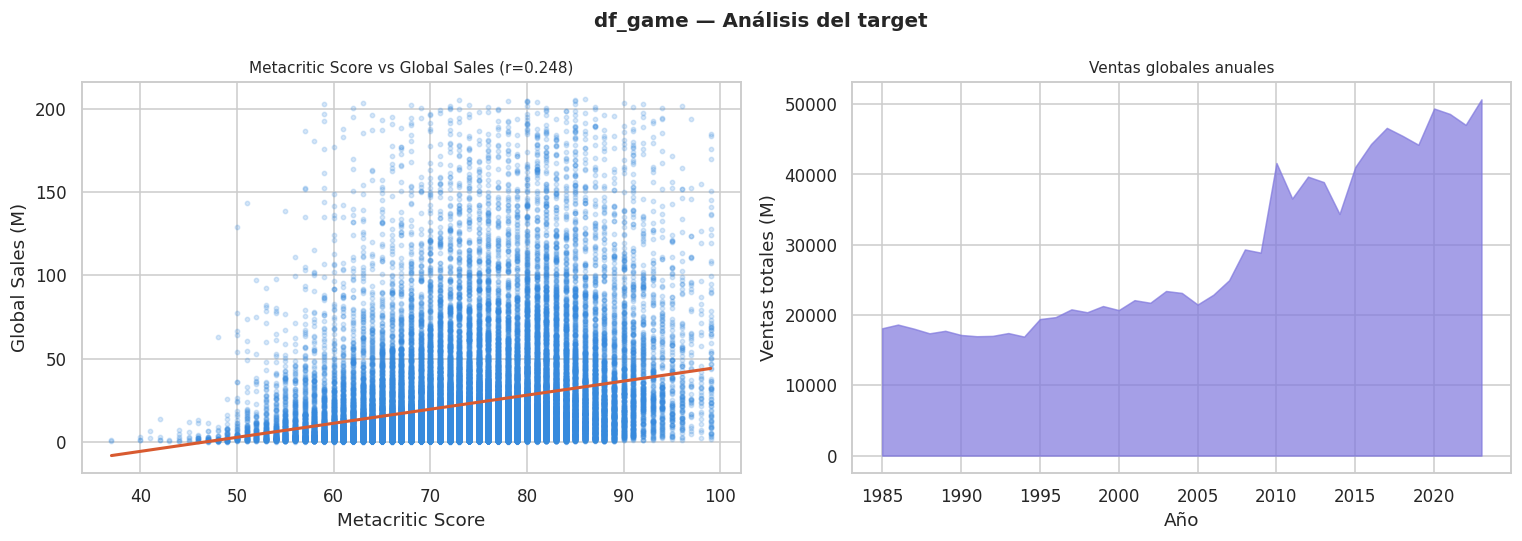

In [ ]:
# Metacritic Score vs Global Sales
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_game_cs = df_game.dropna(subset=['metacritic_score', 'global_sales_million'])
df_game_cs = df_game_cs[df_game_cs['global_sales_million'] <= df_game_cs['global_sales_million'].quantile(0.99)]

axes[0].scatter(df_game_cs['metacritic_score'], df_game_cs['global_sales_million'],
               alpha=0.2, s=8, color='#378ADD')
m, b = np.polyfit(df_game_cs['metacritic_score'], df_game_cs['global_sales_million'], 1)
xr = np.linspace(df_game_cs['metacritic_score'].min(), df_game_cs['metacritic_score'].max(), 100)
axes[0].plot(xr, m*xr+b, color='#D85A30', linewidth=2)
r, _ = stats.pearsonr(df_game_cs['metacritic_score'], df_game_cs['global_sales_million'])
axes[0].set_title(f'Metacritic Score vs Global Sales (r={r:.3f})', fontsize=10)
axes[0].set_xlabel('Metacritic Score')
axes[0].set_ylabel('Global Sales (M)')

# Evolución temporal
if 'year' in df_game.columns:
    yr_game = df_game[df_game['year'].between(1980, 2023)]
    yr_sales = yr_game.groupby('year')['global_sales_million'].sum()
    axes[1].fill_between(yr_sales.index, yr_sales.values, alpha=0.7, color='#7F77DD')
    axes[1].set_title('Ventas globales anuales', fontsize=10)
    axes[1].set_xlabel('Año')
    axes[1].set_ylabel('Ventas totales (M)')

plt.suptitle('df_game — Análisis del target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.4.4 Mapa de calor de correlaciones

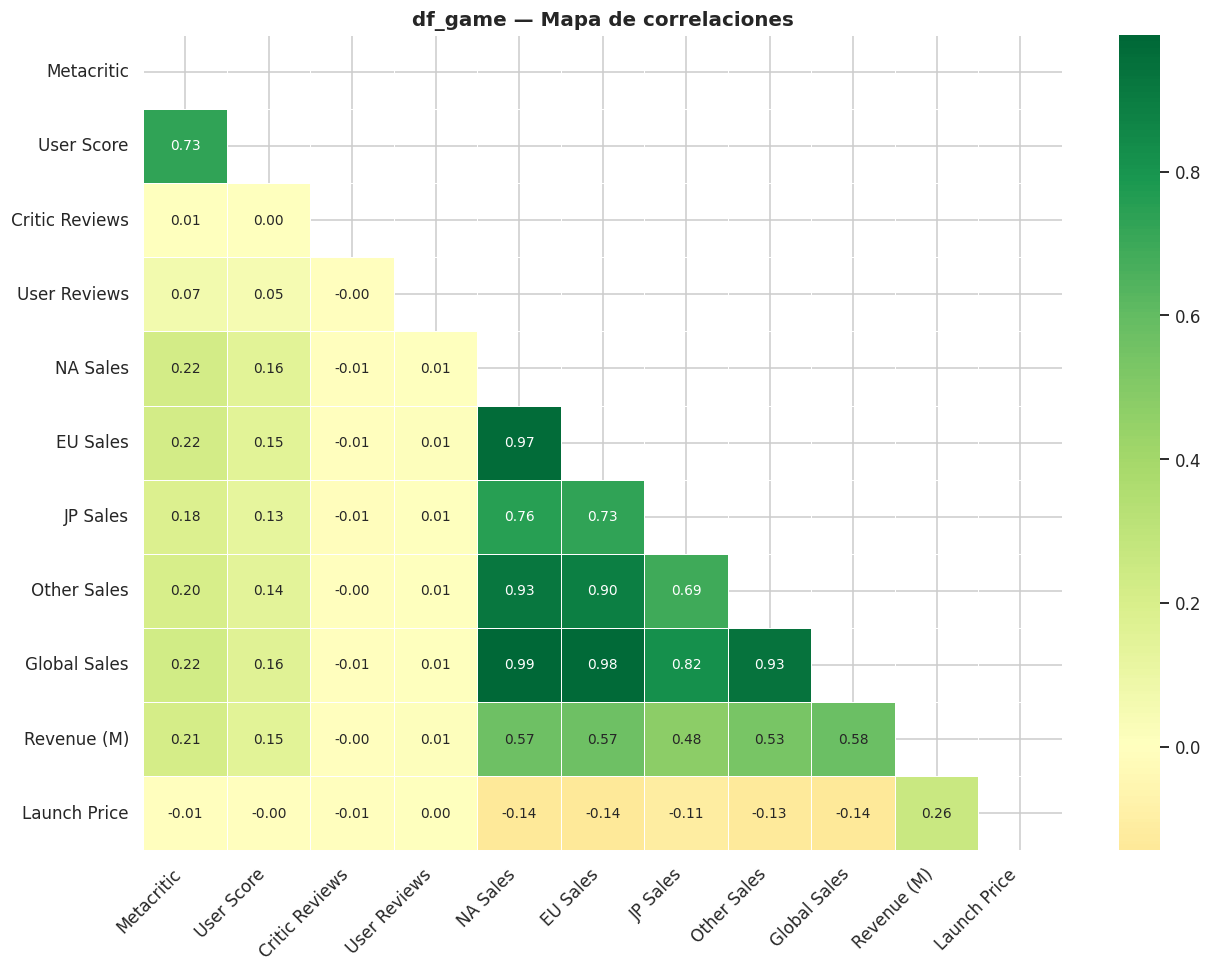


Correlaciones con Global Sales:
NA Sales           0.990
EU Sales           0.977
Other Sales        0.935
JP Sales           0.818
Revenue (M)        0.577
Metacritic         0.224
User Score         0.157
Launch Price      -0.143
User Reviews       0.011
Critic Reviews    -0.006
Name: Global Sales, dtype: object


In [ ]:
num_corr_game = ['metacritic_score', 'user_score', 'critic_review_count', 'user_review_count',
                 'na_sales_million', 'eu_sales_million', 'jp_sales_million',
                 'other_sales_million', 'global_sales_million',
                 'estimated_revenue_million_usd', 'launch_price_usd']
num_corr_game = [c for c in num_corr_game if c in df_game.columns]

corr_game = df_game[num_corr_game].corr()

# Nombres cortos para legibilidad
short_game = {
    'metacritic_score': 'Metacritic', 'user_score': 'User Score',
    'critic_review_count': 'Critic Reviews', 'user_review_count': 'User Reviews',
    'na_sales_million': 'NA Sales', 'eu_sales_million': 'EU Sales',
    'jp_sales_million': 'JP Sales', 'other_sales_million': 'Other Sales',
    'global_sales_million': 'Global Sales',
    'estimated_revenue_million_usd': 'Revenue (M)', 'launch_price_usd': 'Launch Price'
}
corr_game.columns = [short_game.get(c, c) for c in corr_game.columns]
corr_game.index = corr_game.columns

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_game, dtype=bool))
sns.heatmap(corr_game, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, linecolor='white', annot_kws={'size': 9})
plt.title('df_game — Mapa de correlaciones', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('\nCorrelaciones con Global Sales:')
print(corr_game['Global Sales'].drop('Global Sales').sort_values(key=abs, ascending=False).map(lambda x: f'{x:.3f}'))

## 3.5 Identificación de outliers

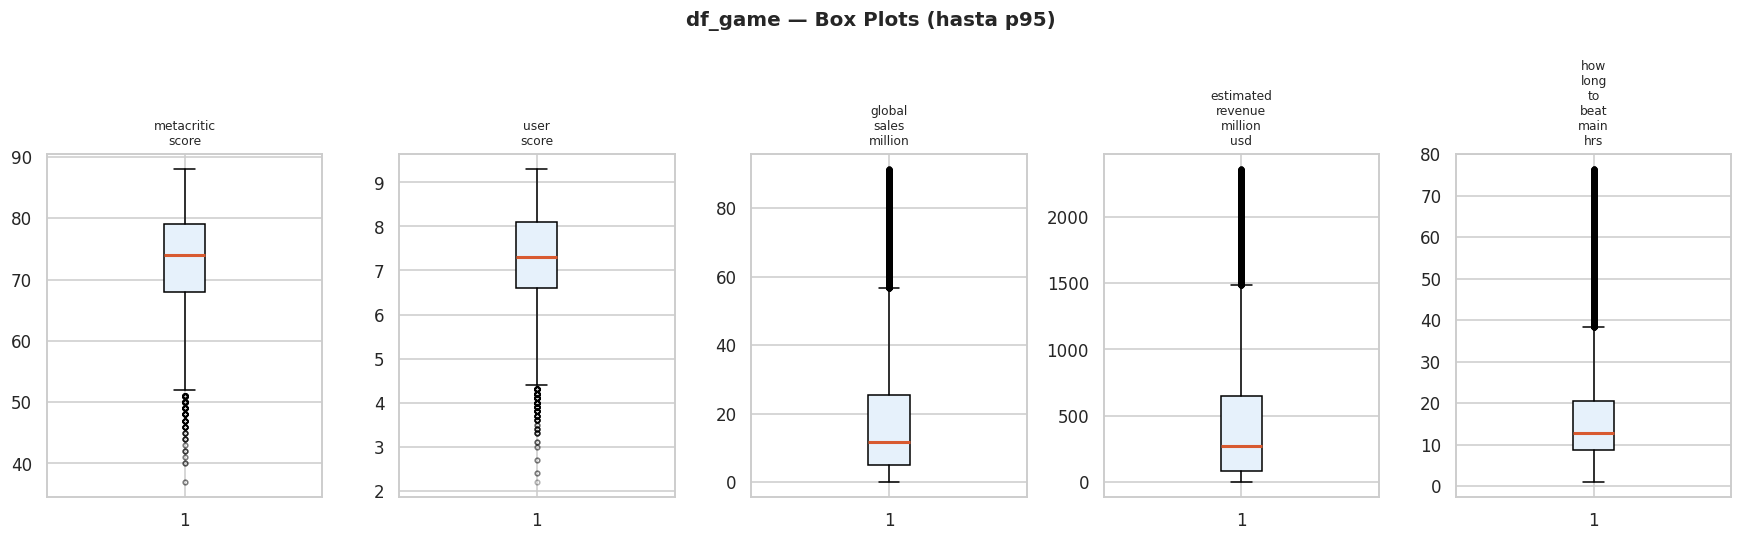


 [df_game] Resumen de outliers (método IQR):


,Variable,Q1,Q3,IQR,N Outliers,% Outliers
0,metacritic_score,68.00,80.00,12.00,219,0.44
1,user_score,6.60,8.20,1.60,153,0.31
2,global_sales_million,5.14,29.29,24.15,4312,8.62
3,estimated_revenue_million_usd,92.59,750.36,657.76,4268,8.54
4,how_long_to_beat_main_hrs,9.00,24.10,15.10,6434,12.87


,Variable,Q1,Q3,IQR,N Outliers,% Outliers
0,metacritic_score,68.00,80.00,12.00,219,0.44
1,user_score,6.60,8.20,1.60,153,0.31
2,global_sales_million,5.14,29.29,24.15,4312,8.62
3,estimated_revenue_million_usd,92.59,750.36,657.76,4268,8.54
4,how_long_to_beat_main_hrs,9.00,24.10,15.10,6434,12.87


In [ ]:
box_cols_game = ['metacritic_score', 'user_score', 'global_sales_million',
                 'estimated_revenue_million_usd', 'how_long_to_beat_main_hrs']
box_cols_game = [c for c in box_cols_game if c in df_game.columns]

fig, axes = plt.subplots(1, len(box_cols_game), figsize=(16, 5))

for i, col in enumerate(box_cols_game):
    ax = axes[i]
    data_vis = df_game[col].dropna()
    data_vis = data_vis[data_vis <= data_vis.quantile(0.95)]
    ax.boxplot(data_vis, patch_artist=True,
               boxprops=dict(facecolor='#E6F1FB'),
               medianprops=dict(color='#D85A30', linewidth=2),
               flierprops=dict(marker='.', alpha=0.3))
    ax.set_title(col.replace('_', '\n'), fontsize=8)

plt.suptitle('df_game — Box Plots (hasta p95)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

resumen_outliers(df_game, box_cols_game, 'df_game')

## 3.10 Resumen de hallazgos — df_game

| Aspecto | Detalle |
|---|---|
| **Tamaño** | 50.000 filas × 34 columnas útiles |
| **Nulos** | Verificados y tratados (nulos en scores y año, quedan imputados con mediana/Unknown) |
| **Duplicados** | Verificados y tratados |
| **Outliers** | Extremos en ventas; transformación log necesaria para modelado |
| **Alta cardinalidad** | `publisher` (500+), `platform` (30+) → requiere agrupación |
| **Distribución** | Ventas fuertemente log-normales (skewness > 10) |
| **Problemática** | **Regresión:** predecir ventas globales de un videojuego |
| **Desafío** | Asimetría extrema del target + alta cardinalidad en categóricas |